In [1]:
print("hello")

hello


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
hp=pd.read_csv("Heart_Disease_Prediction.csv")

In [59]:
hp.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [60]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

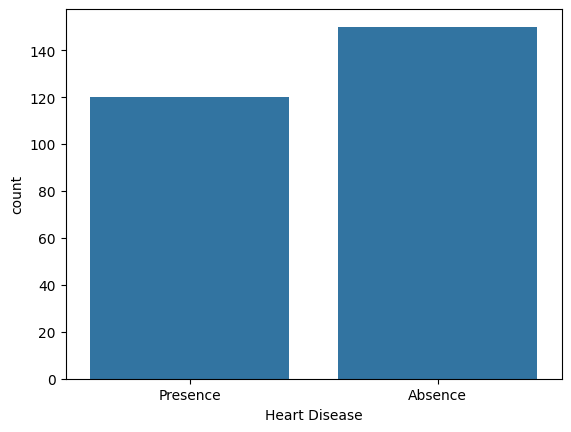

In [61]:
sns.countplot(x='Heart Disease', data=hp)
plt.show()


<Axes: >

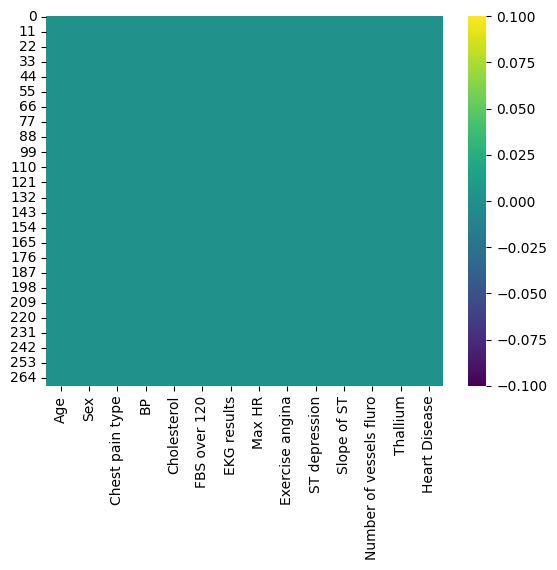

In [62]:
sns.heatmap(hp.isnull(),cmap="viridis")

<Axes: xlabel='Heart Disease', ylabel='count'>

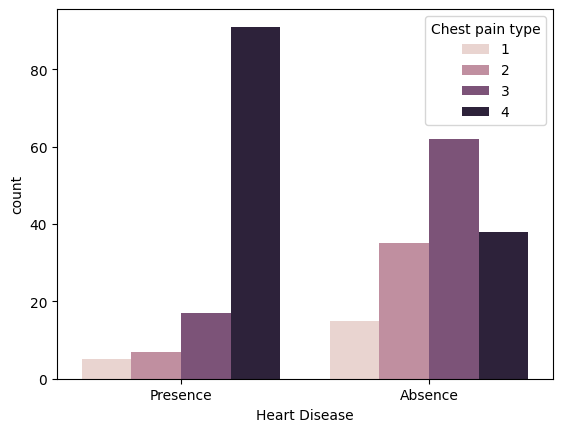

In [63]:
sns.countplot(x="Heart Disease",data=hp,hue="Chest pain type")

<Axes: xlabel='Heart Disease', ylabel='count'>

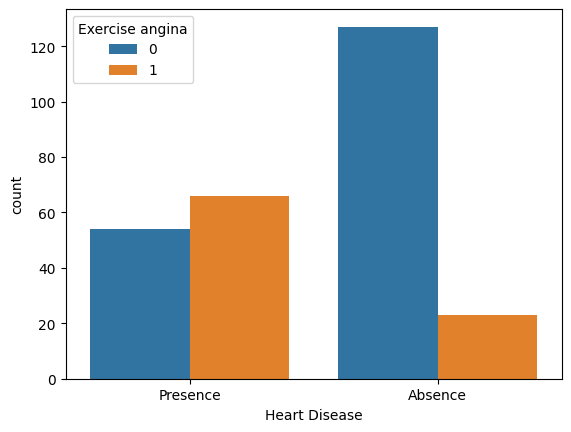

In [64]:
sns.countplot(x='Heart Disease', data=hp, hue='Exercise angina')


<Axes: xlabel='Heart Disease', ylabel='ST depression'>

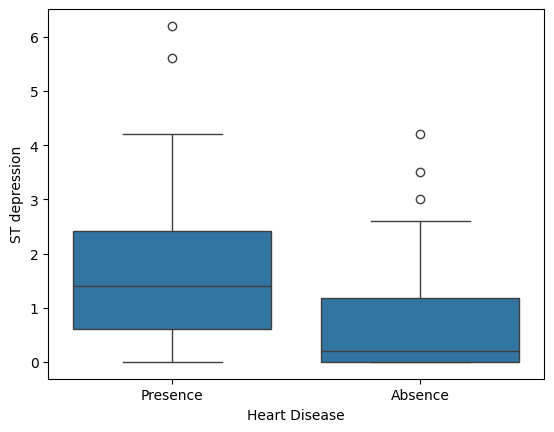

In [65]:
sns.boxplot(x='Heart Disease', y='ST depression', data=hp)


In [66]:
hp['Heart Disease'] = hp['Heart Disease'].map({'Absence': 0, 'Presence': 1})


In [67]:
hp[['Chest pain type', 'Slope of ST', 'Thallium', 'EKG results']]


,Chest pain type,Slope of ST,Thallium,EKG results
0,4,2,3,2
1,3,2,7,2
2,2,1,7,0
3,4,2,7,0
4,2,1,3,2
...,...,...,...,...
265,3,1,7,0
266,2,1,7,0
267,2,2,3,2
268,4,2,6,0


In [68]:
hp['Chest pain type'].unique()

array([4, 3, 2, 1])

In [69]:
hp['Slope of ST'].unique()

array([2, 1, 3])

In [70]:
hp['Thallium'].unique()

array([3, 7, 6])

In [71]:
hp['EKG results'].unique()

array([2, 0, 1])

In [72]:
hp=pd.get_dummies(hp,columns=['Heart Disease'],drop_first=True)

In [73]:
hp

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease_1
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,True
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,False
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,True
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,False
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,False
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,False
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,False
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,False


In [74]:
X = hp.drop('Heart Disease_1', axis=1)
y = hp['Heart Disease_1']

In [75]:
X

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6


In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
lm=LogisticRegression()

In [80]:
lm.fit(X_train,y_train)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [88]:
predictions=lm.predict(X_test)



In [89]:
predictions

array([ True, False,  True, False, False, False, False,  True,  True,
       False, False, False, False, False, False,  True, False,  True,
       False,  True,  True,  True, False,  True,  True, False,  True,
       False,  True, False,  True,  True,  True,  True, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False,  True, False,  True, False, False, False, False,  True,
       False, False, False,  True, False, False, False,  True, False,
        True, False,  True, False,  True,  True, False, False,  True,
        True, False, False, False, False, False, False, False, False])

In [90]:
y_test

193     True
179    False
30      True
97      True
177     True
       ...  
24     False
194    False
96     False
162    False
206    False
Name: Heart Disease_1, Length: 81, dtype: bool

In [91]:
from sklearn.metrics import classification_report

In [92]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

       False       0.80      0.91      0.85        45
        True       0.87      0.72      0.79        36

    accuracy                           0.83        81
   macro avg       0.84      0.82      0.82        81
weighted avg       0.83      0.83      0.82        81

